# 01 — Data exploration

Goal: **look at the data before writing any model code.**
Three things to check:
1. How many images per class (train vs test) — the class imbalance.
2. What the images actually look like, one sample per class.
3. Image sizes and formats — decides the resize target.

Expected folder layout:
```
data/
├── Training/  {glioma, meningioma, pituitary, notumor}/*.jpg
└── Testing/   {glioma, meningioma, pituitary, notumor}/*.jpg
```

In [6]:
from pathlib import Path
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

DATA = Path(r"C:\Users\idirm\Downloads\brain-mri-uncertainty\data")
TRAIN, TEST = DATA / "Training", DATA / "Testing"

assert TRAIN.exists() and TEST.exists(), f"Check the path: {DATA.resolve()}"
CLASSES = sorted([p.name for p in TRAIN.iterdir() if p.is_dir()])
print("Classes:", CLASSES)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 1. Class counts (the imbalance)

In [2]:
def count_images(root):
    return {c: len(list((root / c).glob('*'))) for c in CLASSES}

train_counts, test_counts = count_images(TRAIN), count_images(TEST)
print('Train:', train_counts, '-> total', sum(train_counts.values()))
print('Test :', test_counts,  '-> total', sum(test_counts.values()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (title, counts) in zip(axes, [('Training', train_counts), ('Testing', test_counts)]):
    ax.bar(counts.keys(), counts.values(), color='#7B2CBF')
    ax.set_title(title); ax.set_ylabel('images')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

mx, mn = max(train_counts.values()), min(train_counts.values())
print(f"\nImbalance ratio (train): {mx/mn:.2f}x  (largest / smallest class)")

NameError: name 'TRAIN' is not defined

## 2. One sample per class

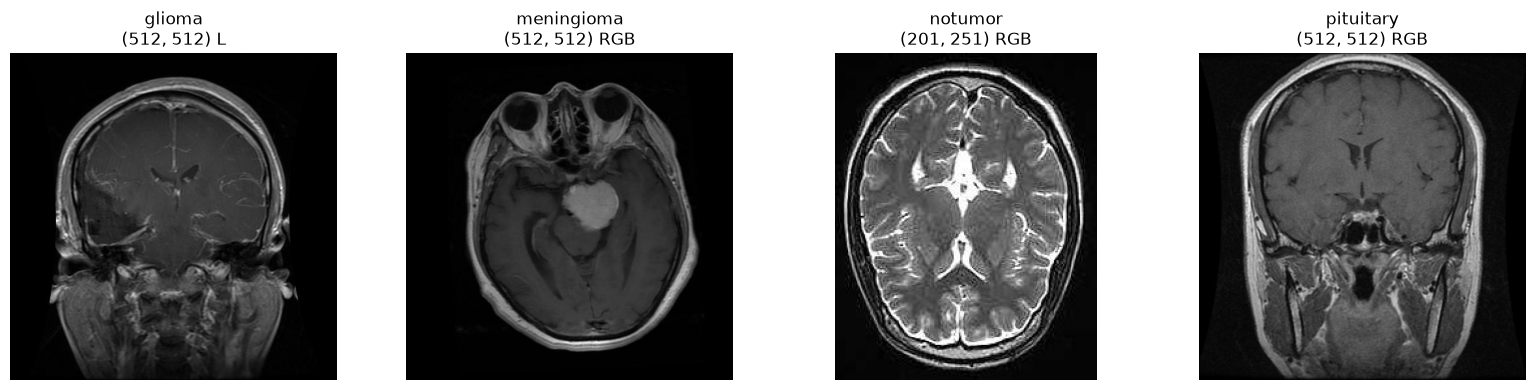

In [10]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(4*len(CLASSES), 4))
for ax, c in zip(axes, CLASSES):
    img_path = next((TRAIN / c).glob('*'))
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray'); ax.set_title(f"{c}\n{img.size} {img.mode}")
    ax.axis('off')
plt.tight_layout(); plt.show()

## 3. Image sizes & modes (decides the resize target)

In [11]:
import random
sizes, modes = Counter(), Counter()
all_train = [p for c in CLASSES for p in (TRAIN / c).glob('*')]
sample = random.sample(all_train, min(400, len(all_train)))
for p in sample:
    im = Image.open(p); sizes[im.size] += 1; modes[im.mode] += 1

print('Most common sizes:', sizes.most_common(5))
print('Modes             :', dict(modes))
print('\nTakeaways to note in docs/decisions.md:')
print(' - resize target (e.g. 224x224)')
print(' - grayscale vs RGB -> if grayscale, replicate to 3 channels for a pretrained encoder')
print(' - imbalance ratio -> weighted loss / macro-F1')

Most common sizes: [((512, 512), 283), ((225, 225), 19), ((630, 630), 7), ((201, 250), 4), ((192, 192), 4)]
Modes             : {'L': 164, 'RGB': 236}

Takeaways to note in docs/decisions.md:
 - resize target (e.g. 224x224)
 - grayscale vs RGB -> if grayscale, replicate to 3 channels for a pretrained encoder
 - imbalance ratio -> weighted loss / macro-F1
